# Этап 1

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Импорт библиотек

In [1]:
from collections import Counter
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from scipy.fft import fft
from scipy.signal import savgol_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import joblib
import ruptures as rpt

Считывание данных из подготовленного файла

In [2]:
data = pd.read_csv('data.csv', header=None, names=['t', 'a', 'klass'])

Считывание данных для обучение модели

In [3]:
train_data = pd.read_csv('train_data.csv', names=['t', 'a', 'klass'])

In [4]:
def extract_features(segment):
    """Извлекает признаки, которые различают 6 классов."""
    N = len(segment)
    features = {}

    # Средний уровень сигнала в сегменте
    seg_mean = np.mean(segment)
    # СКО в сигнала в сегменте
    seg_std = np.std(segment) + 1e-10
    
    # Размах сигнала
    features['norm_range'] = (np.max(segment) - np.min(segment)) / seg_std
    
    # Максимальная производная
    derivative = np.diff(segment)
    features['max_derivative_norm'] = np.max(np.abs(derivative)) / seg_std
    
    # Стандартное отклонение нормализованного сигнала = 1 по определению,
    # но используем отношение max/min отклонения от среднего
    features['max_deviation_norm'] = max(
        np.max(segment) - seg_mean,
        seg_mean - np.min(segment)
    ) / seg_std
    
    # Доля точек, сильно отклоняющихся от среднего
    threshold_low = seg_mean - 1.5 * seg_std
    threshold_high = seg_mean + 1.5 * seg_std
    
    low_points = np.sum(segment < threshold_low) / N
    high_points = np.sum(segment > threshold_high) / N
    
    # Процент точек, сильно ниже среднего
    features['low_points_ratio'] = low_points
    # Процент точек, сильно выше среднего
    features['high_points_ratio'] = high_points
    # Процент "аномальных" точек
    features['extreme_points_ratio'] = low_points + high_points

    # Нормализуем сигнал с помощью Z-масштабирования
    seg_norm = (segment - seg_mean) / seg_std 
    
    yf = fft(seg_norm)
    spectrum = np.abs(yf[:N // 2 + 1])
    harmonics = np.arange(N // 2 + 1)
    max_harmonic = N // 2
    
    # Энергия в полосах
    low_threshold = max(1, int(max_harmonic * 0.1))
    mid_threshold = int(max_harmonic * 0.4)
    
    low_mask = (harmonics >= 1) & (harmonics < low_threshold)
    mid_mask = (harmonics >= low_threshold) & (harmonics < mid_threshold)
    high_mask = harmonics >= mid_threshold
    
    low_energy = np.sum(spectrum[low_mask] ** 2)
    mid_energy = np.sum(spectrum[mid_mask] ** 2)
    high_energy = np.sum(spectrum[high_mask] ** 2)
    total_energy = np.sum(spectrum[1:] ** 2) + 1e-10
    
    # Отношение ВЧ к НЧ
    features['high_to_low_ratio'] = (high_energy + 1e-10) / (low_energy + 1e-10)
    
    # Доля энергии на высоких частотах
    features['high_freq_ratio'] = high_energy / total_energy
    
    # Спектральный центроид
    features['spectral_centroid'] = np.sum(harmonics[1:] * spectrum[1:]) / total_energy / max_harmonic
    
    # Выделение огибающей для замера её наклона
    if N >= 21:
        envelope = savgol_filter(segment, window_length=21, polyorder=3)
    else:
        envelope = segment.copy()
    
    t = np.arange(N)
    slope = np.polyfit(t, envelope, 1)[0]
    features['envelope_slope_norm'] = slope / seg_std
    
    # Размах огибающей
    features['envelope_range_norm'] = (np.max(envelope) - np.min(envelope)) / seg_std

    # Ассиметрия спектра
    half = len(spectrum) // 2
    first_half_energy = np.sum(spectrum[1:half] ** 2)
    second_half_energy = np.sum(spectrum[half:] ** 2)
    features['spectrum_asymmetry'] = (first_half_energy - second_half_energy) / (total_energy + 1e-10)
    
    return features

Подготовка тренировочных данных

In [5]:
SEGMENT_LENGTH = 100
train_segments = []
train_labels = []

for i in range(0, len(train_data) - SEGMENT_LENGTH + 1, SEGMENT_LENGTH):
    segment = train_data['a'].iloc[i:i+SEGMENT_LENGTH].values
    label = train_data['klass'].iloc[i]
    train_segments.append(segment)
    train_labels.append(label)

X = np.array([list(extract_features(seg).values()) for seg in train_segments])
y = np.array(train_labels)

Подготовка данных для предсказания

In [6]:
TEST_SEGMENT_LENGTH = 100
test_segments = []
test_labels = []

for i in range(0, len(data) - TEST_SEGMENT_LENGTH + 1, TEST_SEGMENT_LENGTH):
    segment = data['a'].iloc[i:i+TEST_SEGMENT_LENGTH].values
    label = data['klass'].iloc[i]
    test_segments.append(segment)
    test_labels.append(label)

X_test = np.array([list(extract_features(seg).values()) for seg in test_segments])
y_test = np.array(test_labels)

Обучение модели

In [7]:
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)
#
#param_grid = {
#    'n_estimators': [100, 200, 300, 500],
#    'max_depth': [10, 15, 20, None],
#    'min_samples_split': [2, 5, 10],
#    'min_samples_leaf': [1, 2, 4],
#    'max_features': ['sqrt', 'log2', None],
#}
#
#rf = RandomForestClassifier(random_state=42, class_weight='balanced')
#
#grid_search = GridSearchCV(
#    estimator=rf,
#    param_grid=param_grid,
#    cv=5,
#    scoring='accuracy',
#    n_jobs=-1,
#    verbose=1
#)
#
#grid_search.fit(X_scaled, y)
#
#best_model = grid_search.best_estimator_
#y_pred = best_model.predict(X_test_scaled)
#accuracy = np.mean(y_pred == y_test)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=15, min_samples_leaf=2, class_weight='balanced')
model.fit(X_scaled, y)

y_pred = model.predict(X_test_scaled)
accuracy = np.mean(y_pred == y_test)

In [9]:
accuracy

np.float64(1.0)

In [10]:
y_pred

array([1, 2, 1, 3, 1, 4, 1, 5, 1, 6])

Изобразим предсказание на графике

In [11]:
colors = {
    1: 'green',
    2: 'cyan',    
    3: 'orange',
    4: 'red',    
    5: 'blue',      
    6: 'purple'
}

In [12]:
class_names = {
    1: 'стабильный',
    2: 'плавный рост',
    3: 'плавное падение',
    4: 'резкий обвал',
    5: 'резкий подъем',
    6: 'обвал + подъем'
}

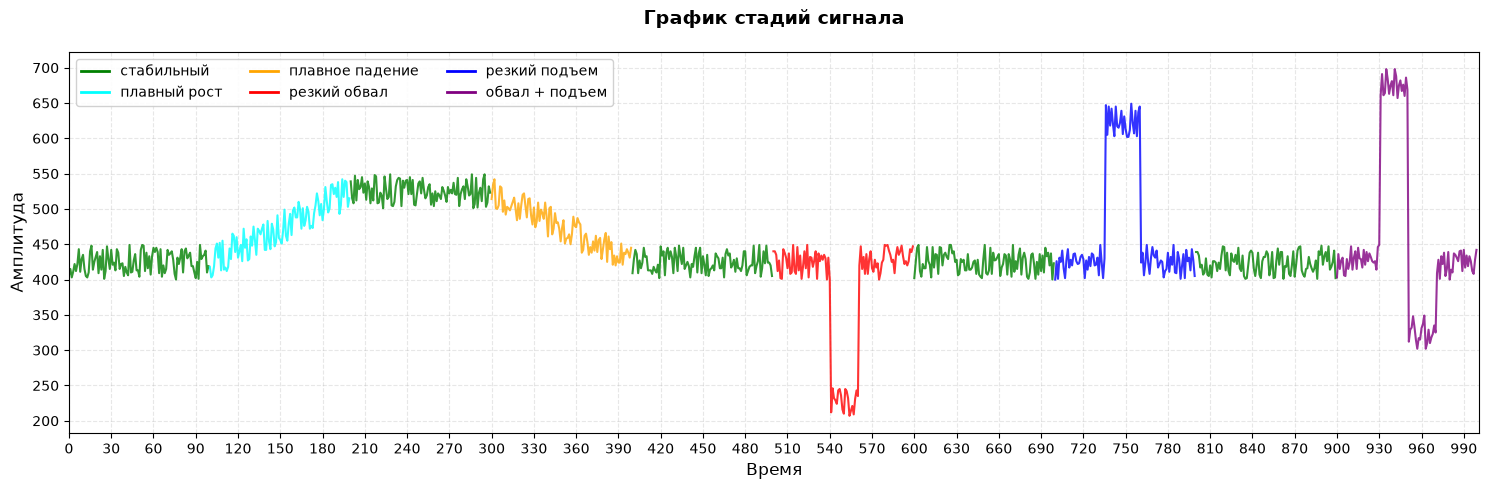

In [13]:
plt.figure(figsize=(15, 5))

for i in range(0, len(data) - 1, SEGMENT_LENGTH):
    segment = data.iloc[i:i+SEGMENT_LENGTH]
    pred_class = y_pred[i//SEGMENT_LENGTH]
    color = colors.get(pred_class, 'black')
    plt.plot(segment['t'], segment['a'], color=color, linewidth=1.5, alpha=0.8)

plt.title('График стадий сигнала', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Амплитуда', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

legend = [Line2D([0], [0], color=colors[k], label=class_names[k], linewidth=2) 
                   for k in sorted(colors.keys())]
plt.legend(handles=legend, loc='upper left', ncol=3, framealpha=0.9)

plt.xlim(0, len(data))
plt.xticks(np.arange(0, len(data)+1, 30))
plt.yticks(np.arange(200, 750, 50))

plt.tight_layout()
plt.show()

Круговая диаграмма

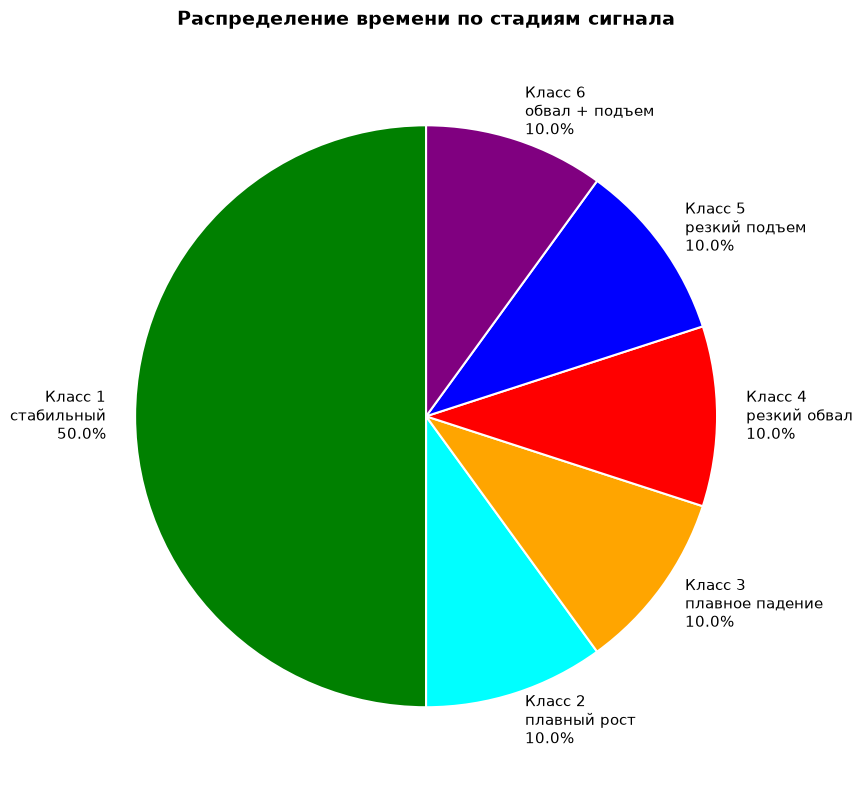

In [14]:
class_counts = {}
for pred_class in y_pred:
    class_counts[pred_class] = class_counts.get(pred_class, 0) + 1

class_counts = dict(sorted(class_counts.items()))

labels = [f"Класс {k}\n{class_names[k]}" for k in class_counts.keys()]
sizes = [count * SEGMENT_LENGTH for count in class_counts.values()]
colors_list = [colors[k] for k in class_counts.keys()]

total = sum(sizes)
percentages = [(s/total)*100 for s in sizes]
labels_with_pct = [f"{labels[i]}\n{percentages[i]:.1f}%" for i in range(len(labels))]

plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(sizes, labels=labels_with_pct, colors=colors_list,
                                    autopct='', startangle=90,
                                    textprops={'fontsize': 11},
                                    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('Распределение времени по стадиям сигнала', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

Проверка модели на больших данных (для этого сгенерирован файл, похожий на train_data.csv)

In [15]:
val_data = pd.read_csv('train_data.csv', names=['t', 'a', 'klass'])

TEST_SEGMENT_LENGTH = 100
val_segments = []
val_labels = []

for i in range(0, len(val_data) - TEST_SEGMENT_LENGTH + 1, TEST_SEGMENT_LENGTH):
    segment = val_data['a'].iloc[i:i+TEST_SEGMENT_LENGTH].values
    label = val_data['klass'].iloc[i]
    val_segments.append(segment)
    val_labels.append(label)

X_big = np.array([list(extract_features(seg).values()) for seg in test_segments])
y_big = np.array(test_labels)

X_big_scaled = scaler.transform(X_big)

y_pred_big = model.predict(X_big_scaled)
accuracy = np.mean(y_pred_big == y_big)
accuracy

np.float64(1.0)

# Реальные данные

## Файл 1

In [19]:
# Считываем данные
df = pd.read_excel('НПС-1 МНА-2.xlsx', header=7)


time_col = df.iloc[:, 0]

vacuum_data = []
vacuum_names = ['V.71400-TT1107VT4X',
                'V.71400-TT1107VT3X',
                'V.71400-TT1107VT2X', 
                'V.71400-TT1107VT1X', 
                'V.71400-TT1107VT4Y', 
                'V.71400-TT1107VT3Y', 
                'V.71400-TT1107VT2Y', 
                'V.71400-TT1107VT1Y']
for i in range(1, 9):
    vacuum_data.append(df.iloc[:, i].values)

vacuum_1_data = df.iloc[:, 1].values
vacuum_2_data = df.iloc[:, 2].values
vacuum_3_data = df.iloc[:, 3].values
vacuum_4_data = df.iloc[:, 4].values
vacuum_5_data = df.iloc[:, 5].values
vacuum_6_data = df.iloc[:, 6].values
vacuum_7_data = df.iloc[:, 7].values
vacuum_8_data = df.iloc[:, 8].values

In [17]:
SEGMENT_LENGTH_1 = 150
segments_1 = []
labels_1 = []

for i in range(0, len(vacuum_1_data) - TEST_SEGMENT_LENGTH + 1, TEST_SEGMENT_LENGTH):
    segment = vacuum_1_data[i:i+SEGMENT_LENGTH]
    segments_1.append(segment)

X_1 = np.array([list(extract_features(seg).values()) for seg in segments_1])

X_1_scaled = scaler.transform(X_1)

y_pred_1 = model.predict(X_1_scaled)

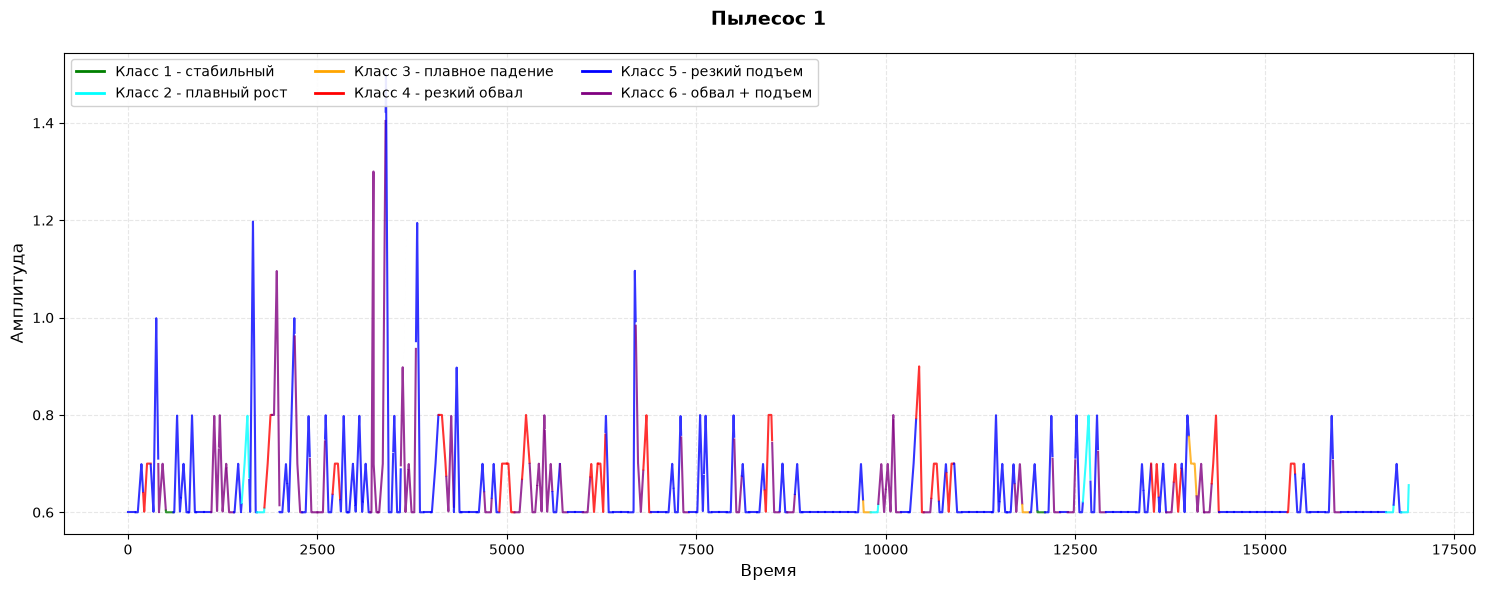

In [18]:
plt.figure(figsize=(15, 6))

for i, (segment, klass) in enumerate(zip(segments_1, y_pred_1)):
    start_idx = i * SEGMENT_LENGTH
    end_idx = start_idx + len(segment)
    time_segment = range(start_idx, end_idx)
    
    color = colors.get(klass, 'black')
    plt.plot(time_segment, segment, color=color, linewidth=1.5, alpha=0.8)

plt.title('Пылесос 1', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Амплитуда', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

legend_elements = [Line2D([0], [0], color=colors[k], label=f"Класс {k} - {class_names[k]}", linewidth=2) 
                   for k in sorted(colors.keys())]
plt.legend(handles=legend_elements, loc='upper left', ncol=3, framealpha=0.9)

plt.tight_layout()
plt.show()

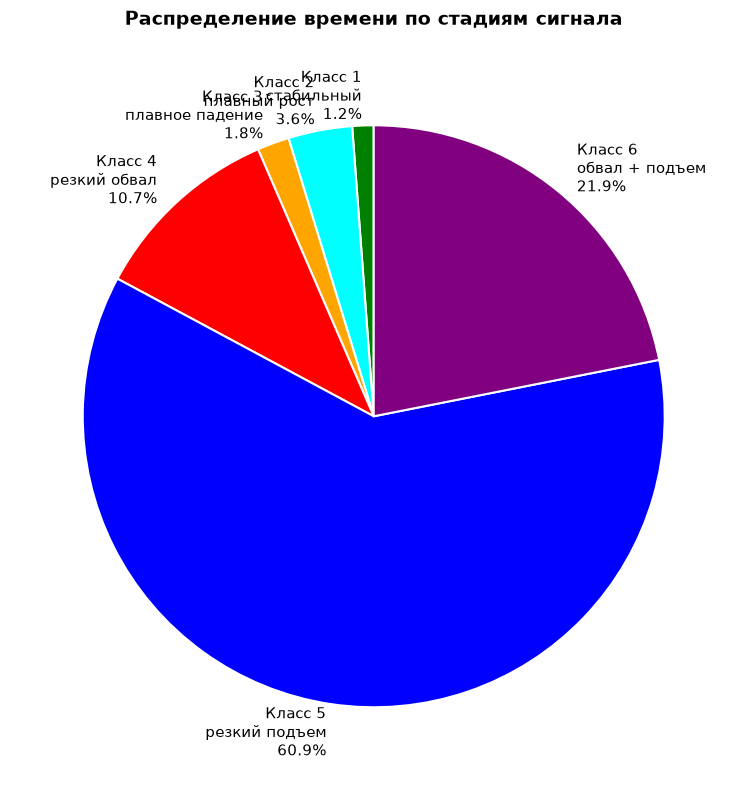

In [19]:
class_counts = {}
for pred_class in y_pred_1:
    class_counts[pred_class] = class_counts.get(pred_class, 0) + 1

class_counts = dict(sorted(class_counts.items()))

labels = [f"Класс {k}\n{class_names[k]}" for k in class_counts.keys()]
sizes = [count * SEGMENT_LENGTH for count in class_counts.values()]
colors_list = [colors[k] for k in class_counts.keys()]

total = sum(sizes)
percentages = [(s/total)*100 for s in sizes]
labels_with_pct = [f"{labels[i]}\n{percentages[i]:.1f}%" for i in range(len(labels))]

plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(sizes, labels=labels_with_pct, colors=colors_list,
                                    autopct='', startangle=90,
                                    textprops={'fontsize': 11},
                                    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('Распределение времени по стадиям сигнала', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

Модель не вполне справляется с классификацией. Очень мало стабильных участков, даже в местах, где они должны были определится. Необходимо дообучение.

### Использование PELT

Решена проблема с тем, что длину сегментов необходимо задавать вручную

In [20]:
# Алгоритм PELT для поиска точек разрыва
algo = rpt.Pelt(model="rbf", min_size=100).fit(vacuum_1_data)
penalty = 3.0
breakpoints = algo.predict(pen=penalty)

print(f"Найдено {len(breakpoints)-1} сегментов")

segments = []
segment_starts = []
segment_ends = []
features_list = []

for i in range(len(breakpoints) - 1):
    start = breakpoints[i]
    end = breakpoints[i + 1]
    seg = vacuum_1_data[start:end]
    
    feats = extract_features(seg)
    if feats is not None:
        segments.append(seg)
        segment_starts.append(start)
        segment_ends.append(end)
        features_list.append(feats)

X_new = np.array([list(f.values()) for f in features_list])
X_new_scaled = scaler.transform(X_new)
segment_classes = model.predict(X_new_scaled).ravel()

Найдено 105 сегментов


График

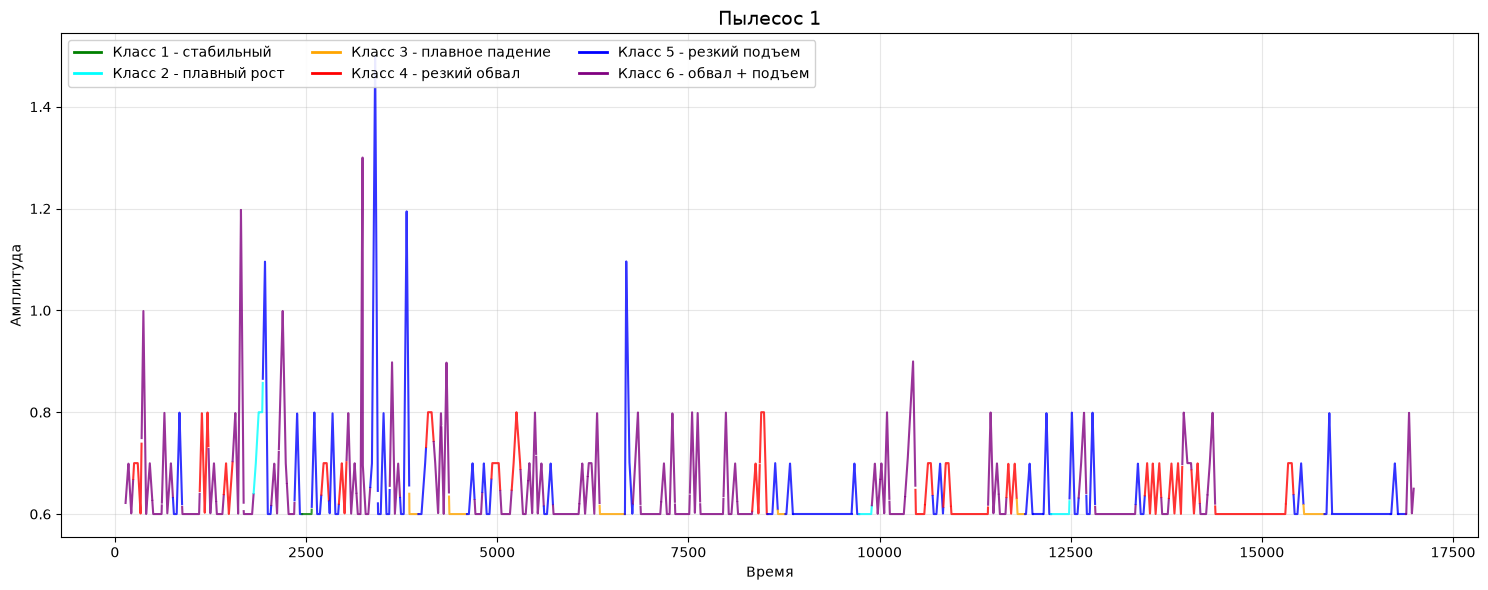

In [21]:
plt.figure(figsize=(15, 6))

for seg, start, end, klass in zip(segments, segment_starts, segment_ends, segment_classes):
    time_range = range(start, end)
    color = colors.get(klass, 'black')
    plt.plot(time_range, seg, color=color, linewidth=1.5, alpha=0.8)

plt.title('Пылесос 1', fontsize=14)
plt.xlabel('Время')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)

legend_elements = [Line2D([0], [0], color=colors[k], label=f"Класс {k} - {class_names[k]}", linewidth=2) 
                   for k in sorted(colors.keys())]
plt.legend(handles=legend_elements, loc='upper left', ncol=3, framealpha=0.9)

plt.tight_layout()
plt.show()

Статистика

In [22]:
class_counts = Counter(segment_classes)
print("Распределение классов:")
for klass in sorted(class_counts.keys()):
    count = class_counts[klass]
    total_length = sum([segment_ends[i] - segment_starts[i] 
                        for i in range(len(segments)) if segment_classes[i] == klass])
    pct = (count / len(segments)) * 100
    print(f"Класс {klass} ({class_names[klass]}): {count} сегментов, {total_length} точек ({pct:.1f}%)")

Распределение классов:
Класс 1 (стабильный): 1 сегментов, 125 точек (1.0%)
Класс 2 (плавный рост): 3 сегментов, 525 точек (2.9%)
Класс 3 (плавное падение): 6 сегментов, 1170 точек (5.7%)
Класс 4 (резкий обвал): 20 сегментов, 3540 точек (19.0%)
Класс 5 (резкий подъем): 29 сегментов, 4635 точек (27.6%)
Класс 6 (обвал + подъем): 46 сегментов, 6852 точек (43.8%)


### Переобучение модели

Было принято решение поменять логику извлечения признаков для классификации. Кроме того, теперь будет выделено 3 класса: 'стабильный', 'плавные изменения', 'резкие изменения'.

In [ ]:
def extract_features_v2(segment):
    """Извлекает признаки с робастной нормализацией."""
    N = len(segment)
    if N < 10:
        return None
    
    features = {}
    seg_std = np.std(segment) + 1e-10
    
    # Робастная оценка разброса
    median = np.median(segment)
    mad = np.median(np.abs(segment - median)) + 1e-10
    
    # Абсолютный размах
    features['abs_range'] = np.max(segment) - np.min(segment)
    
    # Абсолютная максимальная производная
    derivative = np.diff(segment)
    features['abs_max_derivative'] = np.max(np.abs(derivative))
    
    # Абсолютное максимальное отклонение от медианы
    features['abs_max_deviation'] = max(
        np.max(segment) - median,
        median - np.min(segment)
    )
    
    features['norm_range'] = features['abs_range'] / mad
    features['max_derivative_norm'] = features['abs_max_derivative'] / mad
    features['max_deviation_norm'] = features['abs_max_deviation'] / mad
    
    threshold_low = median - 3 * mad
    threshold_high = median + 3 * mad
    
    low_points = np.sum(segment < threshold_low) / N
    high_points = np.sum(segment > threshold_high) / N
    
    features['low_points_ratio'] = low_points
    features['high_points_ratio'] = high_points
    features['extreme_points_ratio'] = low_points + high_points

    seg_norm = (segment - median) / mad
    yf = fft(seg_norm)
    spectrum = np.abs(yf[:N // 2 + 1])
    harmonics = np.arange(N // 2 + 1)
    max_harmonic = N // 2
    
    low_threshold = max(1, int(max_harmonic * 0.1))
    mid_threshold = int(max_harmonic * 0.4)
    
    low_mask = (harmonics >= 1) & (harmonics < low_threshold)
    high_mask = harmonics >= mid_threshold
    
    low_energy = np.sum(spectrum[low_mask] ** 2)
    high_energy = np.sum(spectrum[high_mask] ** 2)
    total_energy = np.sum(spectrum[1:] ** 2) + 1e-10
    
    features['high_to_low_ratio'] = (high_energy + 1e-10) / (low_energy + 1e-10)
    features['high_freq_ratio'] = high_energy / total_energy
    features['spectral_centroid'] = np.sum(harmonics[1:] * spectrum[1:]) / total_energy / max_harmonic
    
    if N >= 21:
        envelope = savgol_filter(segment, window_length=21, polyorder=3)
    else:
        envelope = segment.copy()
    
    t = np.arange(N)
    slope = np.polyfit(t, envelope, 1)[0]
    features['envelope_slope_norm'] = slope / mad
    features['envelope_range_norm'] = (np.max(envelope) - np.min(envelope)) / mad
    
    half = len(spectrum) // 2
    first_half_energy = np.sum(spectrum[1:half] ** 2)
    second_half_energy = np.sum(spectrum[half:] ** 2)
    features['spectrum_asymmetry'] = (first_half_energy - second_half_energy) / (total_energy + 1e-10)
    
    features['mad_std_ratio'] = mad / seg_std
    
    return features

Обучаем модель

In [21]:
df_train = pd.read_excel('vacuum_data.xlsx', header=None)
df_train.columns = ['amplitude', 'class']

# Разбиваем на сегменты по изменению класса
df_train['segment_id'] = (df_train['class'] != df_train['class'].shift()).cumsum()

segments = []
labels = []

for segment_id, group in df_train.groupby('segment_id'):
    segment_data = group['amplitude'].values
    label = group['class'].iloc[0]
    
    if len(segment_data) >= 10:  # Пропускаем слишком короткие
        segments.append(segment_data)
        labels.append(label)

# Извлекаем признаки
features_list = []
valid_segments = []
valid_labels = []

for seg, label in zip(segments, labels):
    feats = extract_features_v2(seg)
    if feats is not None:
        features_list.append(feats)
        valid_segments.append(seg)
        valid_labels.append(label)

# Преобразуем в массивы
feature_names = list(features_list[0].keys())
X = np.array([list(f.values()) for f in features_list])
y = np.array(valid_labels)

# Масштабирование и обучение
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

model.fit(X_scaled, y)

# Сохраняем модель
joblib.dump(model, 'vacuum_model_3classes.pkl')
joblib.dump(scaler, 'vacuum_scaler_3classes.pkl')
joblib.dump(feature_names, 'vacuum_feature_names.pkl')

['vacuum_feature_names.pkl']

In [22]:
colors = {
    1: 'green',
    2: 'cyan',    
    3: 'red'
}

class_names = {
    1: 'стабильный',
    2: 'плавные изменения',
    3: 'резкие изменения'
}


Графики для первого файла

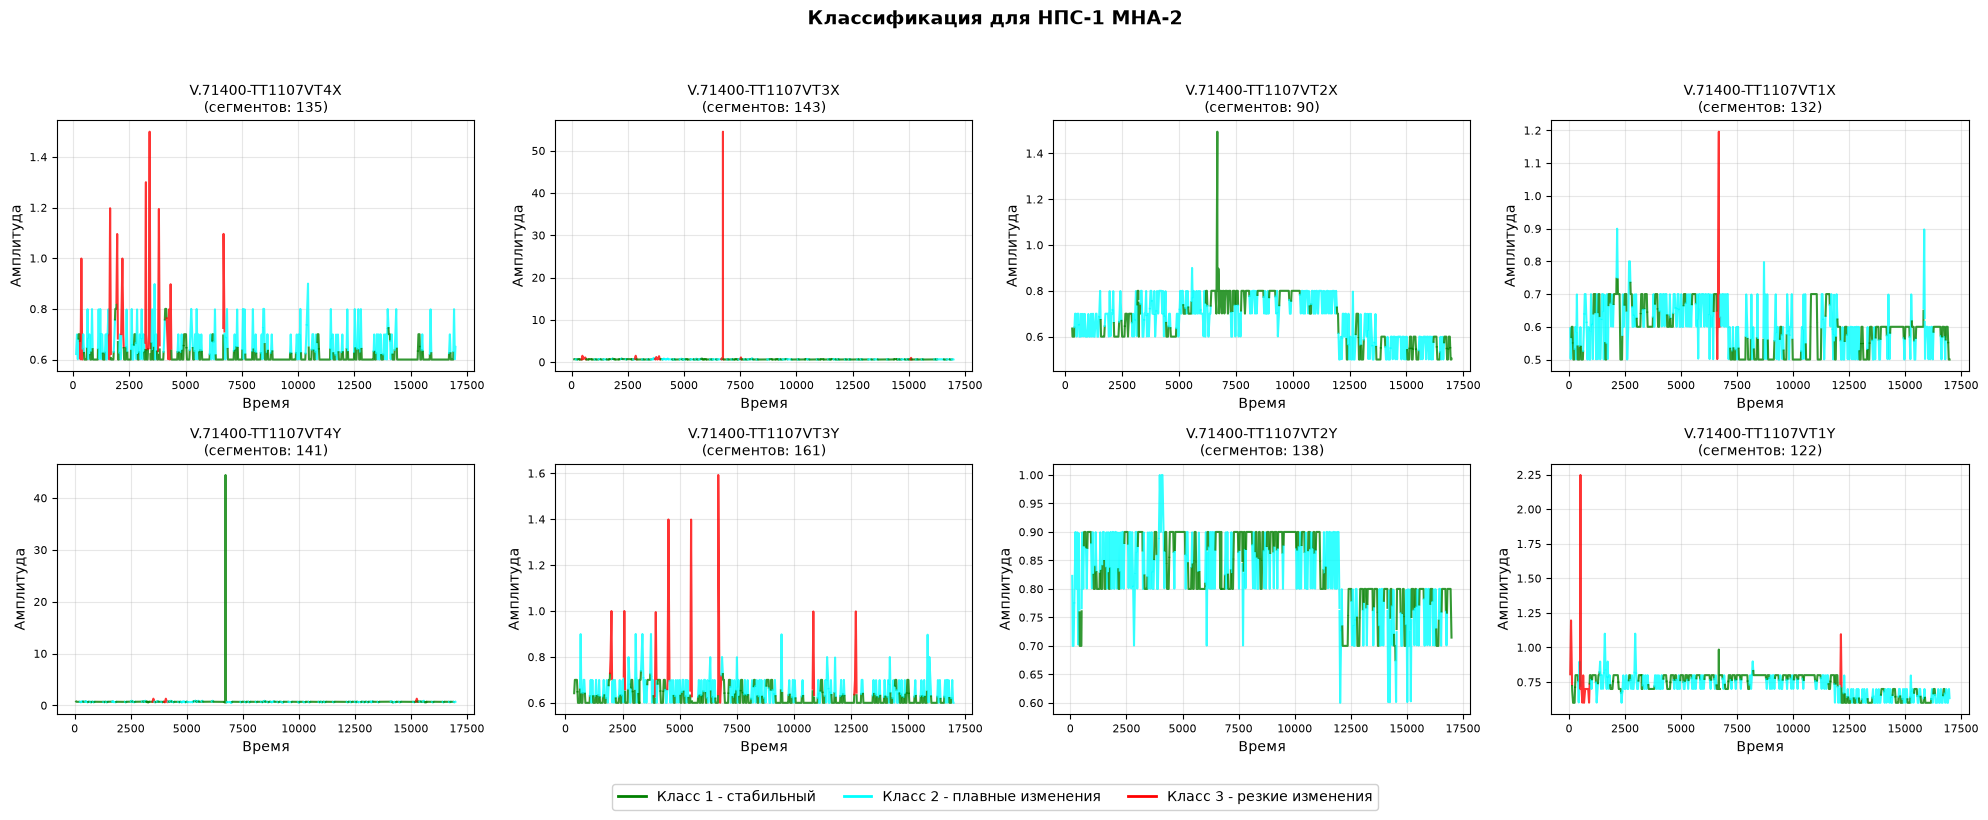

In [ ]:
# Гиперпараметры для PELT
penalty = 15.0
min_size = 50

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for idx, (data, name) in enumerate(zip(vacuum_data, vacuum_names)):
    # Сегментация
    algo = rpt.Pelt(model="rbf", min_size=min_size).fit(data)
    breakpoints = algo.predict(pen=penalty)
    
    # Извлечение признаков и классификация
    segments = []
    starts = []
    ends = []
    features_list = []
    
    for i in range(len(breakpoints) - 1):
        start = breakpoints[i]
        end = breakpoints[i + 1]
        seg = data[start:end]
        
        feats = extract_features_v2(seg)
        if feats is not None:
            segments.append(seg)
            starts.append(start)
            ends.append(end)
            features_list.append(feats)
    
    # Классификация
    X = np.array([list(f.values()) for f in features_list])
    X_scaled = scaler.transform(X)
    classes = model.predict(X_scaled)
    
    # Построение графика
    ax = axes[idx]
    
    for seg, start, end, klass in zip(segments, starts, ends, classes):
        time_range = range(start, end)
        color = colors.get(klass, 'black')
        ax.plot(time_range, seg, color=color, linewidth=1.5, alpha=0.8)
    
    ax.set_title(f'{name}\n(сегментов: {len(segments)})', fontsize=10)
    ax.set_xlabel('Время')
    ax.set_ylabel('Амплитуда')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

legend_elements = [Line2D([0], [0], color=colors[k], label=f"Класс {k} - {class_names[k]}", linewidth=2) 
                   for k in sorted(colors.keys())]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), 
           ncol=3, framealpha=0.9, fontsize=10)

plt.suptitle('Классификация для НПС-1 МНА-2', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()